# Calculate Flux Density

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy import ndimage
import warnings
import sys

from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import skycoord_to_pixel
from astropy.coordinates import SkyCoord
import astropy.constants as const
au = const.au.cgs.value
pc = const.pc.cgs.value

In [788]:
stokeI_color = 'inferno'

In [789]:
distance_pc = 140
crop_sizeau = 250
ra_min = '16:32:22.652'
ra_max = '16:32:22.568'
# dec_min = '-24:28:33.28'
# dec_max = '-24:28:32.12'

dec_min = '-24:28:33.18'
dec_max = '-24:28:32.02'

coord_min = SkyCoord(ra=ra_min, dec=dec_min, unit=('hourangle','deg'))
coord_max = SkyCoord(ra=ra_max, dec=dec_max, unit=('hourangle','deg'))

In [790]:
def get_info(fname):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        with fits.open(fname) as hdul:
            data = hdul[0].data
            header = hdul[0].header
        # with warnings.catch_warnings():
        #     warnings.simplefilter('ignore')
            wcs = WCS(header=header)
    return data, header, wcs

def get_beam_axis(header, distance_pc):
    au_per_pix = abs(header['CDELT1'])/180*np.pi*distance_pc*pc/au
    if 'BMAJ' in header and 'BMIN' in header and 'BPA' in header:
        beam_major_arcsec = header['BMAJ'] * 3600  # Major axis in arcseconds
        beam_minor_arcsec = header['BMIN'] * 3600  # Minor axis in arcseconds
        beam_major_pixels = (header['BMAJ']/180*np.pi)*distance_pc*pc/au / au_per_pix
        beam_minor_pixels = (header['BMIN']/180*np.pi)*distance_pc*pc/au / au_per_pix
        beam_pa = header['BPA']  # Position angle in degrees
    else:
        raise ValueError("Beam size (BMAJ and BMIN) not found in FITS header.")
    return (beam_major_arcsec, beam_minor_arcsec), (beam_major_pixels, beam_minor_pixels), beam_pa, au_per_pix

def crop(data, wcs):
    """
    Crop the data to the specified coordinates.
    """
    # Convert sky coordinates to pixel coordinates
    min_pixel = skycoord_to_pixel(coord_min, wcs)
    max_pixel = skycoord_to_pixel(coord_max, wcs)

    # Calculate pixel indices
    x_min, y_min = int(min_pixel[0]), int(min_pixel[1])
    x_max, y_max = int(max_pixel[0]), int(max_pixel[1])

    # Crop the data
    cropped_data = data[y_min:y_max, x_min:x_max]
    cropped_wcs = wcs.slice(slice(y_min, y_max), slice(x_min, x_max))
    return cropped_data, cropped_wcs

In [791]:
fname_band6_stokeI  = '/home/hyp0515/project_data/IRAS16293/image_FITS/ALMA_Band6_Pol/c2d_1008_Stokes.I.regrid.fits'
fname_band6_stokeI_highres = '/home/hyp0515/project_data/IRAS16293/image_FITS/ALMA_Band6_Pol/iras16293B_cont_b6_foralpha_pbcor.fits'
fname_band3_stokeI  = '/home/hyp0515/project_data/IRAS16293/image_FITS/ALMA_Band3_StokesI/sourceB.image.dropdreg.fits'
fname_qband_stokeI  = '/home/hyp0515/project_data/IRAS16293/image_FITS/JVLA_Qband_Pol/iras16293_Qband.rob0.I.regrid.fits'
fname_kuband_stokeI = '/home/hyp0515/project_data/IRAS16293/image_FITS/JVLA_Kuband_Pol/rob0/I16293_Kuband_A.rob0.I.image.tt0.pbcor.subim.fits'

In [ ]:
def get_flux_density(fname, rms):
    data, header, wcs = get_info(fname=fname)
    beam_arcsec, beam_pixel, beam_pa, au_per_pix = get_beam_axis(header=header, distance_pc=distance_pc)
    beam_major_arcsec, beam_minor_arcsec = beam_arcsec
    beam_major_pixels, beam_minor_pixels = beam_pixel
    beam_area_pixels = np.pi * beam_major_pixels * beam_minor_pixels / (4 * np.log(2))
    if fname == fname_band6_stokeI_highres:
        data_crop, wcs_crop = crop(data[0, 0, :, :], wcs)
    else:
        data_crop, wcs_crop = crop(data, wcs)
    mask = data_crop > 5 * rms
    data_crop[~mask] = np.nan
    total_flux = np.nansum(data_crop) / beam_area_pixels
    uncertainty = rms * mask.sum() / beam_area_pixels
    print(f"Total flux density : {total_flux*1e3:.3f} mJy")
    print(f"Uncertainty : {uncertainty*1e3:.3f} mJy")
    return total_flux, uncertainty

## Band 6

In [793]:
flux_band6, uncertainty_band6 = get_flux_density(fname_band6_stokeI_highres, 104e-6)
wavelength_band6 = .13
freq_band6 = const.c.cgs.value / wavelength_band6 * 1e-9 # in GHz
print(f"Frequency Band 6: {freq_band6:.3f} GHz")

Total flux density : 1171.466 mJy
Uncertainty : 10.290 mJy
Frequency Band 6: 230.610 GHz


In [794]:
flux_band3, uncertainty_band3 = get_flux_density(fname_band3_stokeI, 17e-6)
wavlength_band3 = .3
freq_band3 = const.c.cgs.value / wavlength_band3 * 1e-9 # in GHz
print(f"Frequency Band 3: {freq_band3:.3f} GHz")

Total flux density : 216.434 mJy
Uncertainty : 3.398 mJy
Frequency Band 3: 99.931 GHz


In [795]:
flux_qband, uncertainty_qband = get_flux_density(fname_qband_stokeI, 47e-6)
wavelength_qband = .7
freq_qband = const.c.cgs.value / wavelength_qband * 1e-9 # in GHz
print(f"Frequency Q band: {freq_qband:.3f} GHz")

Total flux density : 32.545 mJy
Uncertainty : 0.363 mJy
Frequency Q band: 42.827 GHz


In [796]:
flux_kuband, uncertainty_kuband = get_flux_density(fname_kuband_stokeI, 47e-6)
wavlength_kuband = 1.8
freq_kuband = const.c.cgs.value / wavlength_kuband * 1e-9 # in GHz
print(f"Frequency Ku band: {freq_kuband:.3f} GHz")

Total flux density : 2.407 mJy
Uncertainty : 0.218 mJy
Frequency Ku band: 16.655 GHz


In [797]:
data_band6, header_band6, wcs_band6 = get_info(fname_band6_stokeI_highres)

In [798]:
beam_arcsec, beam_pixel, beam_pa, au_per_pix = get_beam_axis(header=header_band6, distance_pc=distance_pc)
beam_major_arcsec, beam_minor_arcsec = beam_arcsec
beam_major_pixels, beam_minor_pixels = beam_pixel

print(f"Beam major axis: {beam_major_arcsec:.4f} arcsec")
print(f"Beam minor axis: {beam_minor_arcsec:.4f} arcsec")
print(f"Beam major axis: {beam_major_pixels:.4f} pixels")
print(f"Beam minor axis: {beam_minor_pixels:.4f} pixels")
print(f"Beam position angle: {beam_pa:.2f} degrees")

Beam major axis: 0.1143 arcsec
Beam minor axis: 0.0694 arcsec
Beam major axis: 11.4250 pixels
Beam minor axis: 6.9395 pixels
Beam position angle: -88.21 degrees


In [799]:
beam_area_pixels = np.pi * beam_major_pixels * beam_minor_pixels / (4 * np.log(2))
print(f"Beam area: {beam_area_pixels:.4f} pixels^2")

Beam area: 89.8365 pixels^2


In [800]:
data_band6_crop, wcs_band6_crop = crop(data_band6[0, 0, :, :], wcs_band6)

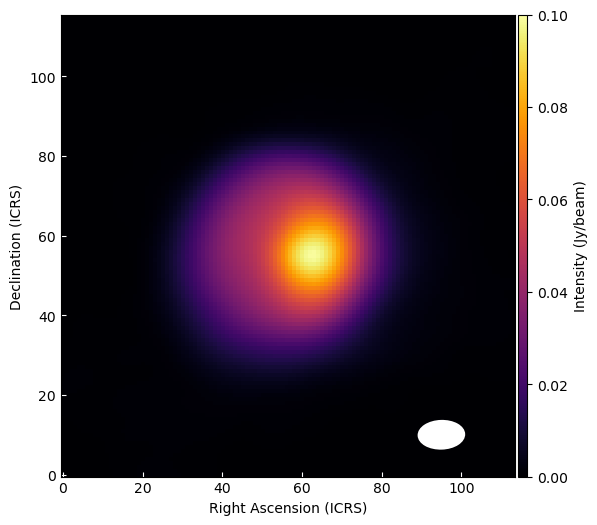

In [801]:
fig = plt.figure(figsize=(8, 6))
# ax = plt.subplot(projection=wcs_band6_crop)
ax = plt.subplot()

im = ax.imshow(data_band6_crop, cmap=stokeI_color, origin='lower', vmin=0.00, vmax=0.1)
colorbar = fig.colorbar(im, ax=ax, pad=0.005, aspect=50)
colorbar.set_label('Intensity (Jy/beam)')

beam = Ellipse((95, 10), width=beam_minor_pixels, height=beam_major_pixels,
               angle=beam_pa, edgecolor='w', facecolor='w', lw=1.5, fill=True)
ax.add_patch(beam)

# plt.plot([25-75/au_per_pix, 25+75/au_per_pix],[10, 10], "w", lw=3)
# plt.text(25, 15, '150 AU', color='w', ha='center', va='top')
ax.set_xlabel('Right Ascension (ICRS)')
ax.set_ylabel('Declination (ICRS)')
plt.tick_params(direction='in', color='w')
# plt.savefig('iras16293_Band6_conti.pdf', transparent=True)
plt.show()




In [802]:
rms = 104e-6

In [803]:
mask = data_band6_crop > 5 * rms
data_band6_crop[~mask] = np.nan

In [804]:
print(f"Number of pixels > 5*rms: {mask.sum()}")

Number of pixels > 5*rms: 7676


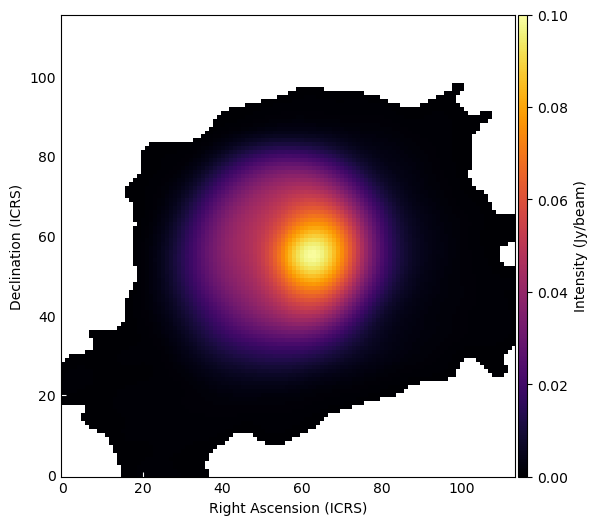

In [805]:
fig = plt.figure(figsize=(8, 6))
# ax = plt.subplot(projection=wcs_band6_crop)
ax = plt.subplot()

im = ax.imshow(data_band6_crop, cmap=stokeI_color, origin='lower', vmin=0.00, vmax=0.1)
colorbar = fig.colorbar(im, ax=ax, pad=0.005, aspect=50)
colorbar.set_label('Intensity (Jy/beam)')

beam = Ellipse((95, 10), width=beam_minor_pixels, height=beam_major_pixels,
               angle=beam_pa, edgecolor='w', facecolor='w', lw=1.5, fill=True)
ax.add_patch(beam)

# plt.plot([25-75/au_per_pix, 25+75/au_per_pix],[10, 10], "w", lw=3)
# plt.text(25, 15, '150 AU', color='w', ha='center', va='top')
ax.set_xlabel('Right Ascension (ICRS)')
ax.set_ylabel('Declination (ICRS)')
plt.tick_params(direction='in', color='w')
# plt.savefig('iras16293_Band6_conti.pdf', transparent=True)
plt.show()




In [806]:
total_flux = np.nansum(data_band6_crop) / beam_area_pixels
uncertainty = rms * mask.sum() / beam_area_pixels
print(f"Total flux (Jy): {total_flux:.4f}")
print(f"Uncertainty (Jy): {uncertainty:.4f}")

Total flux (Jy): 1.1658
Uncertainty (Jy): 0.0089


## Band 3

In [807]:
data_band3, header_band3, wcs_band3 = get_info(fname_band3_stokeI)

In [808]:
beam_arcsec, beam_pixel, beam_pa, au_per_pix = get_beam_axis(header=header_band3, distance_pc=distance_pc)
beam_major_arcsec, beam_minor_arcsec = beam_arcsec
beam_major_pixels, beam_minor_pixels = beam_pixel

print(f"Beam major axis: {beam_major_arcsec:.4f} arcsec")
print(f"Beam minor axis: {beam_minor_arcsec:.4f} arcsec")
print(f"Beam major axis: {beam_major_pixels:.4f} pixels")
print(f"Beam minor axis: {beam_minor_pixels:.4f} pixels")
print(f"Beam position angle: {beam_pa:.2f} degrees")

Beam major axis: 0.0478 arcsec
Beam minor axis: 0.0442 arcsec
Beam major axis: 7.9684 pixels
Beam minor axis: 7.3654 pixels
Beam position angle: 79.33 degrees


In [809]:
data_band3_crop, wcs_band3_crop = crop(data_band3, wcs_band3)

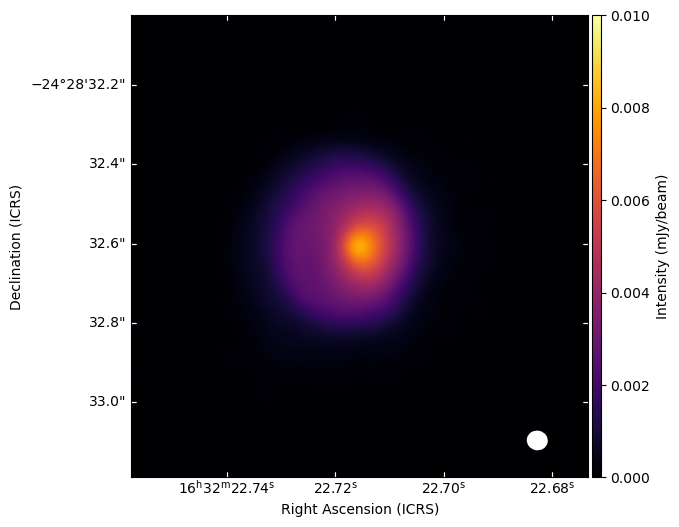

In [810]:
fig = plt.figure(figsize=(8, 6))
ax = plt.subplot(projection=wcs_band3_crop)
ax = plt.subplot()

im = ax.imshow(data_band3_crop, cmap=stokeI_color, origin='lower', vmin=0.00, vmax=0.01)
colorbar = fig.colorbar(im, ax=ax, pad=0.005, aspect=50)
colorbar.set_label('Intensity (mJy/beam)')

beam = Ellipse((170, 15), width=beam_minor_pixels, height=beam_major_pixels,
               angle=beam_pa, edgecolor='w', facecolor='w', lw=1.5, fill=True)
ax.add_patch(beam)

# plt.plot([25-75/au_per_pix, 25+75/au_per_pix],[10, 10], "w", lw=3)
# plt.text(25, 15, '150 AU', color='w', ha='center', va='top')
ax.set_xlabel('Right Ascension (ICRS)')
ax.set_ylabel('Declination (ICRS)')
plt.tick_params(direction='in', color='w')
plt.savefig('iras16293_Band3_conti.pdf', transparent=True)
plt.show()

In [811]:
rms = 17e-6

In [812]:
mask = data_band3_crop > 5 * rms
data_band3_crop[~mask] = np.nan

In [813]:
print(f"Number of pixels > 5*rms: {mask.sum()}")

Number of pixels > 5*rms: 10299


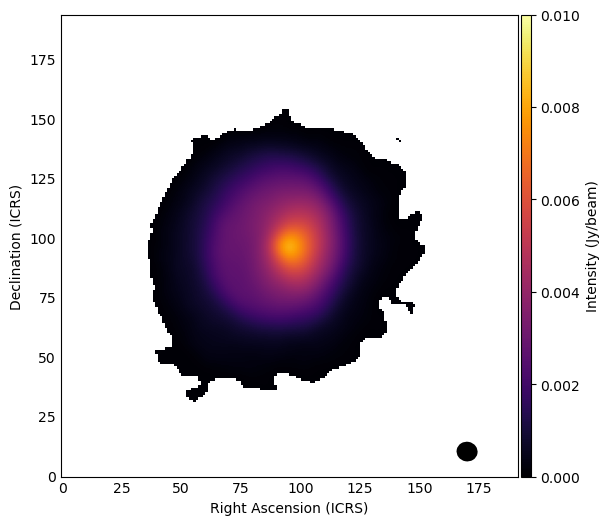

In [814]:
fig = plt.figure(figsize=(8, 6))
# ax = plt.subplot(projection=wcs_band6_crop)
ax = plt.subplot()

im = ax.imshow(data_band3_crop, cmap=stokeI_color, origin='lower', vmin=0.00, vmax=0.01)
colorbar = fig.colorbar(im, ax=ax, pad=0.005, aspect=50)
colorbar.set_label('Intensity (Jy/beam)')

beam = Ellipse((170, 10), width=beam_minor_pixels, height=beam_major_pixels,
               angle=beam_pa, edgecolor='k', facecolor='k', lw=1.5, fill=True)
ax.add_patch(beam)

# plt.plot([25-75/au_per_pix, 25+75/au_per_pix],[10, 10], "w", lw=3)
# plt.text(25, 15, '150 AU', color='w', ha='center', va='top')
ax.set_xlabel('Right Ascension (ICRS)')
ax.set_ylabel('Declination (ICRS)')
plt.tick_params(direction='in', color='w')
# plt.savefig('iras16293_Band6_conti.pdf', transparent=True)
plt.show()




In [815]:
total_flux = np.nansum(data_band3_crop) / beam_area_pixels
uncertainty = rms * mask.sum() / beam_area_pixels
print(f"Total flux (Jy): {total_flux:.4f}")
print(f"Uncertainty (Jy): {uncertainty:.4f}")

Total flux (Jy): 0.1581
Uncertainty (Jy): 0.0019


## Q Band

In [816]:
data_qband, header_qband, wcs_qband = get_info(fname_qband_stokeI)

In [817]:
beam_arcsec, beam_pixel, beam_pa, au_per_pix = get_beam_axis(header=header_qband, distance_pc=distance_pc)
beam_major_arcsec, beam_minor_arcsec = beam_arcsec
beam_major_pixels, beam_minor_pixels = beam_pixel

print(f"Beam major axis: {beam_major_arcsec:.4f} arcsec")
print(f"Beam minor axis: {beam_minor_arcsec:.4f} arcsec")
print(f"Beam major axis: {beam_major_pixels:.4f} pixels")
print(f"Beam minor axis: {beam_minor_pixels:.4f} pixels")
print(f"Beam position angle: {beam_pa:.2f} degrees")

Beam major axis: 0.3932 arcsec
Beam minor axis: 0.2482 arcsec
Beam major axis: 65.5330 pixels
Beam minor axis: 41.3715 pixels
Beam position angle: 73.75 degrees


In [818]:
data_qband_crop, wcs_qband_crop = crop(data_qband, wcs_qband)

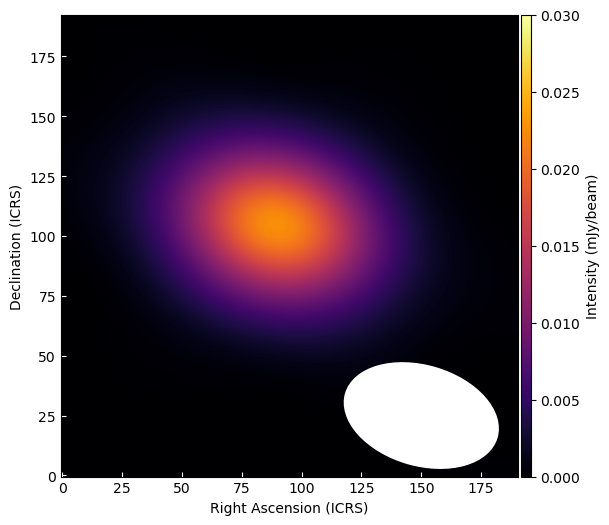

In [819]:
fig = plt.figure(figsize=(8, 6))
# ax = plt.subplot(projection=wcs_band6_crop)
ax = plt.subplot()

im = ax.imshow(data_qband_crop, cmap=stokeI_color, origin='lower', vmin=0.00, vmax=0.03)
colorbar = fig.colorbar(im, ax=ax, pad=0.005, aspect=50)
colorbar.set_label('Intensity (mJy/beam)')

beam = Ellipse((150, 25), width=beam_minor_pixels, height=beam_major_pixels,
               angle=beam_pa, edgecolor='w', facecolor='w', lw=1.5, fill=True)
ax.add_patch(beam)

# plt.plot([25-75/au_per_pix, 25+75/au_per_pix],[10, 10], "w", lw=3)
# plt.text(25, 15, '150 AU', color='w', ha='center', va='top')
ax.set_xlabel('Right Ascension (ICRS)')
ax.set_ylabel('Declination (ICRS)')
plt.tick_params(direction='in', color='w')
# plt.savefig('iras16293_QBand_conti.pdf', transparent=True)
plt.show()



In [820]:
rms = 47e-6

In [821]:
mask = data_qband_crop > 5 * rms
data_qband_crop[~mask] = np.nan

In [822]:
print(f"Number of pixels > 5*rms: {mask.sum()}")

Number of pixels > 5*rms: 21390


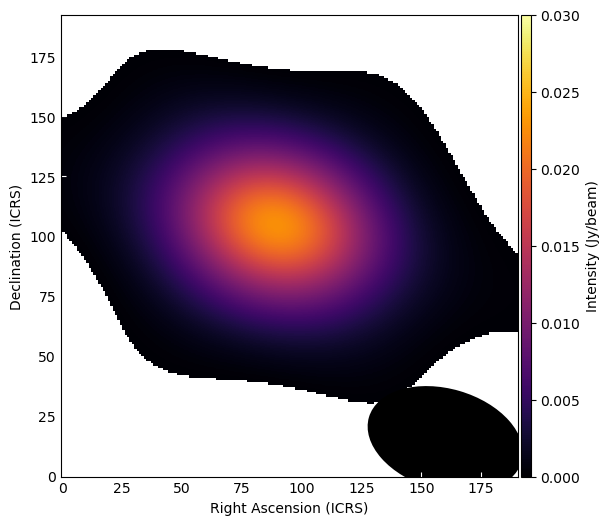

In [823]:
fig = plt.figure(figsize=(8, 6))
# ax = plt.subplot(projection=wcs_band6_crop)
ax = plt.subplot()

im = ax.imshow(data_qband_crop, cmap=stokeI_color, origin='lower', vmin=0.00, vmax=0.03)
colorbar = fig.colorbar(im, ax=ax, pad=0.005, aspect=50)
colorbar.set_label('Intensity (Jy/beam)')

beam = Ellipse((160, 15), width=beam_minor_pixels, height=beam_major_pixels,
               angle=beam_pa, edgecolor='k', facecolor='k', lw=1.5, fill=True)
ax.add_patch(beam)

# plt.plot([25-75/au_per_pix, 25+75/au_per_pix],[10, 10], "w", lw=3)
# plt.text(25, 15, '150 AU', color='w', ha='center', va='top')
ax.set_xlabel('Right Ascension (ICRS)')
ax.set_ylabel('Declination (ICRS)')
plt.tick_params(direction='in', color='w')
# plt.savefig('iras16293_Band6_conti.pdf', transparent=True)
plt.show()

In [824]:
total_flux = np.nansum(data_qband_crop) / beam_area_pixels
uncertainty = rms * mask.sum() / beam_area_pixels
print(f"Total flux (Jy): {total_flux:.4f}")
print(f"Uncertainty (Jy): {uncertainty:.4f}")

Total flux (Jy): 1.1082
Uncertainty (Jy): 0.0112


## Ku Band

In [825]:
data_kuband, header_kuband, wcs_kuband = get_info(fname_kuband_stokeI)

In [826]:
beam_arcsec, beam_pixel, beam_pa, au_per_pix = get_beam_axis(header=header_kuband, distance_pc=distance_pc)
beam_major_arcsec, beam_minor_arcsec = beam_arcsec
beam_major_pixels, beam_minor_pixels = beam_pixel

print(f"Beam major axis: {beam_major_arcsec:.4f} arcsec")
print(f"Beam minor axis: {beam_minor_arcsec:.4f} arcsec")
print(f"Beam major axis: {beam_major_pixels:.4f} pixels")
print(f"Beam minor axis: {beam_minor_pixels:.4f} pixels")
print(f"Beam position angle: {beam_pa:.2f} degrees")

Beam major axis: 0.2252 arcsec
Beam minor axis: 0.0944 arcsec
Beam major axis: 15.0147 pixels
Beam minor axis: 6.2967 pixels
Beam position angle: 5.19 degrees


In [827]:
data_kuband_crop, wcs_kuband_crop = crop(data_kuband, wcs_kuband)

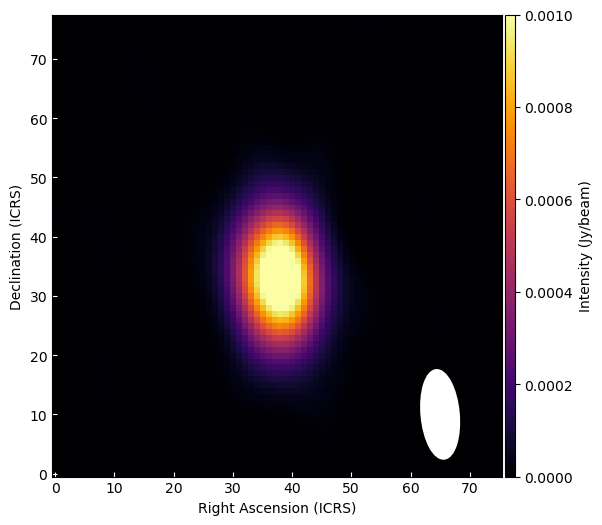

In [828]:
fig = plt.figure(figsize=(8, 6))
# ax = plt.subplot(projection=wcs_band6_crop)
ax = plt.subplot()

im = ax.imshow(data_kuband_crop, cmap=stokeI_color, origin='lower', vmin=0.00, vmax=0.001)
colorbar = fig.colorbar(im, ax=ax, pad=0.005, aspect=50)
colorbar.set_label('Intensity (Jy/beam)')

beam = Ellipse((65, 10), width=beam_minor_pixels, height=beam_major_pixels,
               angle=beam_pa, edgecolor='w', facecolor='w', lw=1.5, fill=True)
ax.add_patch(beam)

# plt.plot([25-75/au_per_pix, 25+75/au_per_pix],[10, 10], "w", lw=3)
# plt.text(25, 15, '150 AU', color='w', ha='center', va='top')
ax.set_xlabel('Right Ascension (ICRS)')
ax.set_ylabel('Declination (ICRS)')
plt.tick_params(direction='in', color='w')
# plt.savefig('iras16293_KuBand_conti.pdf', transparent=True)
plt.show()


In [829]:
rms = 47e-6

In [830]:
mask = data_kuband_crop > 5 * rms
data_kuband_crop[~mask] = np.nan

In [831]:
print(f"Number of pixels > 5*rms: {mask.sum()}")

Number of pixels > 5*rms: 378


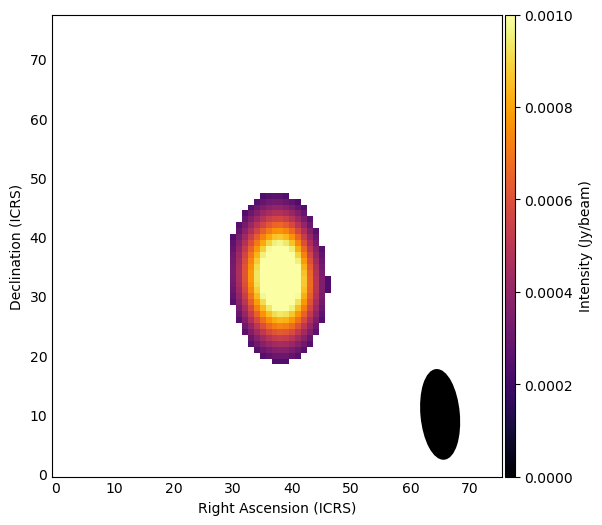

In [832]:
fig = plt.figure(figsize=(8, 6))
# ax = plt.subplot(projection=wcs_band6_crop)
ax = plt.subplot()

im = ax.imshow(data_kuband_crop, cmap=stokeI_color, origin='lower', vmin=0.00, vmax=0.001)
colorbar = fig.colorbar(im, ax=ax, pad=0.005, aspect=50)
colorbar.set_label('Intensity (Jy/beam)')

beam = Ellipse((65, 10), width=beam_minor_pixels, height=beam_major_pixels,
               angle=beam_pa, edgecolor='k', facecolor='k', lw=1.5, fill=True)
ax.add_patch(beam)

# plt.plot([25-75/au_per_pix, 25+75/au_per_pix],[10, 10], "w", lw=3)
# plt.text(25, 15, '150 AU', color='w', ha='center', va='top')
ax.set_xlabel('Right Ascension (ICRS)')
ax.set_ylabel('Declination (ICRS)')
plt.tick_params(direction='in', color='w')
# plt.savefig('iras16293_Band6_conti.pdf', transparent=True)
plt.show()




In [833]:
total_flux = np.nansum(data_kuband_crop) / beam_area_pixels
uncertainty = rms * mask.sum() / beam_area_pixels
print(f"Total flux (Jy): {total_flux:.4f}")
print(f"Uncertainty (Jy): {uncertainty:.4f}")

Total flux (Jy): 0.0026
Uncertainty (Jy): 0.0002
